## 1. Dependências e configuração

In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

%pip install -q numpy pandas matplotlib scipy scikit-learn ruptures PyWavelets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, json, glob, gc, tempfile, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import ruptures as rpt
import pywt
import IPython.display as ipd
from tqdm.auto import tqdm

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

# Compatibilidade NumPy >= 2.0 (np.trapz renomeado para np.trapezoid)
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

# Diretórios
ROOT_DIR   = 'data'
SIGNAL_DIR = os.path.join(ROOT_DIR, 'signals')
L1_DIR     = os.path.join(ROOT_DIR, 'level1_signals')
VIZ_DIR    = os.path.join(ROOT_DIR, 'nb2_viz')
LOG_DIR    = os.path.join(ROOT_DIR, 'logs')
OUT_JSON   = os.path.join(ROOT_DIR, 'preictal_estimate.json')
for d in [L1_DIR, VIZ_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# Rótulos das classes
LBL = dict(interictal=0, preictal=1, ictal=2, postictal=3, unknown=-1)

# Pacientes (12 por dataset; Mendeley com 6)
PATIENTS = {
    'CHBMIT'  : ['chb01','chb03','chb04','chb05','chb06','chb07',
                 'chb08','chb10','chb11','chb12','chb13','chb14'],
    'Siena'   : ['PN01','PN03','PN05','PN06','PN07',
                 'PN09','PN10','PN11','PN12','PN13','PN14','PN16'],
    'Mendeley': ['p10','p11','p12','p13','p14','p15'],
    'SeizeIT2': ['sub-001','sub-002','sub-003','sub-004','sub-005','sub-006',
                 'sub-007','sub-008','sub-009','sub-010','sub-011','sub-012'],
}
DATASETS = ['CHBMIT','Siena','Mendeley','SeizeIT2']
DS_COLORS = {'CHBMIT':'#4C72B0','Siena':'#DD8452','Mendeley':'#55A868','SeizeIT2':'#C44E52'}

# Parâmetros do estimador
LOOKBACK_SEC     = 60*60
FEAT_WIN_SEC     = 30
FEAT_STEP_SEC    = 30
PELT_PENALTY     = 3.0
PELT_MIN_SIZE    = 3
MIN_PREICTAL_SEC = 3*60
MAX_PREICTAL_SEC = 50*60
SIL_THRESHOLD    = 0.30

# Parâmetros de rotulagem (PRE_SEC definido na seção 5)
POST_SEC      = 20*60
GUARD_SEC     = 5*60
MIN_PRE_SEC   = 5*60

# Parâmetros do interictal por intervalo intra-arquivo (Siena, Mendeley)
GAP_FREE_SEC    = 60*60
POST_MARGIN_SEC = 90*60
GAP_FALLBACKS   = [60*60, 45*60, 30*60]
GAP_DATASETS    = {'Siena', 'Mendeley'}

# Rótulos de canais temporais (transição pré-ictal mais saliente nessas derivações)
TEMPORAL_HINTS = ['t3','t4','t5','t6','t7','t8','p7','p8','ft9','ft10','tp7','tp8','f7','f8']
_BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

signals_available = sorted(glob.glob(os.path.join(SIGNAL_DIR, '*_signal.npz')))
print('Configuração carregada.')
print(f'Sinais disponíveis: {len(signals_available)}')
print(f'PELT: penalidade {PELT_PENALTY}, tamanho mínimo de segmento {PELT_MIN_SIZE}')
print(f'Interictal por intervalo intra-arquivo: {sorted(GAP_DATASETS)} | margem pós-crise {POST_MARGIN_SEC//60} min')

Configuração carregada.
Sinais disponíveis: 314
PELT: penalidade 3.0, tamanho mínimo de segmento 3
Interictal por intervalo intra-arquivo: ['Mendeley', 'Siena'] | margem pós-crise 90 min


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Extração de features e estimador

`channel_feats` calcula 15 features de um canal (5 temporais, 6 espectrais, 4 DWT). `temporal_channel_indices` seleciona, pelos rótulos dos canais, as derivações temporais; quando nenhuma é reconhecida, usa todos os canais. `extract_preonset_features` monta a série temporal de features anterior ao início da crise, e `estimate_preictal_window` aplica o PELT e valida com K-Means.


In [3]:
def channel_feats(sig, sfreq):
    '''15 features de um canal: 5 temporais, 6 espectrais, 4 DWT.'''
    d1 = np.diff(sig)
    act = float(np.var(sig))
    mob = float(np.sqrt(np.var(d1) / (act + 1e-10)))
    temporal = [float(np.std(sig)), act, float(np.sqrt(np.mean(sig**2))),
                float(np.sum(np.abs(d1))), mob]
    nperseg = min(int(sfreq), max(int(sfreq // 2), len(sig) // 2))
    nperseg = max(min(nperseg, len(sig)), 2)
    f, psd = welch(sig, fs=sfreq, nperseg=nperseg)
    bp = []
    for lo, hi in _BANDS.values():
        idx = (f >= lo) & (f <= hi)
        bp.append(float(np.trapz(psd[idx], f[idx])) if idx.sum() > 1 else 0.0)
    pn = psd / (psd.sum() + 1e-10); pn = pn[pn > 0]
    spectral = bp + [float(-np.sum(pn * np.log(pn)))]
    ml = min(4, pywt.dwt_max_level(len(sig), 'db4')) if len(sig) > 1 else 0
    if ml >= 1:
        coeffs = pywt.wavedec(sig.astype(np.float64), 'db4', level=ml)
        dwt = [float(np.sum(x**2)) for x in coeffs[1:5]]
        while len(dwt) < 4:
            dwt.append(0.0)
    else:
        dwt = [0.0] * 4
    return np.array(temporal + spectral + dwt, dtype=np.float32)

def temporal_channel_indices(ch_names):
    '''Índices dos canais temporais a partir de seus rótulos.'''
    idx = [i for i, c in enumerate(ch_names) if any(h in str(c).lower() for h in TEMPORAL_HINTS)]
    return idx if idx else list(range(len(ch_names)))

def extract_preonset_features(data, sfreq, ch_names, onset_sample, prev_offset=0):
    '''Série temporal de features (média sobre canais temporais) antes do início da crise.'''
    ws = int(FEAT_WIN_SEC * sfreq); step = int(FEAT_STEP_SEC * sfreq); look = int(LOOKBACK_SEC * sfreq)
    ch_idx = temporal_channel_indices(ch_names)
    win_start = max(0, onset_sample - look, prev_offset)
    if onset_sample - win_start < ws:
        return np.empty((0, 15), dtype=np.float32), np.empty(0)
    feats, starts = [], []
    for s in range(win_start, onset_sample - ws + 1, step):
        seg = data[ch_idx, s:s + ws]
        if seg.shape[1] < 8 or not np.isfinite(seg).all():
            continue
        try:
            fvec = np.mean([channel_feats(seg[c], sfreq) for c in range(seg.shape[0])], axis=0)
            feats.append(fvec); starts.append((s - onset_sample) / sfreq / 60)
        except Exception:
            continue
    if not feats:
        return np.empty((0, 15), dtype=np.float32), np.empty(0)
    return np.array(feats, dtype=np.float32), np.array(starts)

def estimate_preictal_window(feats, starts_min):
    '''PELT + validação por K-Means. Retorna (dur_min, cp_min, n_cp, silhueta, X_norm).'''
    if len(feats) < 2 * PELT_MIN_SIZE:
        return None, None, 0, None, None
    Xn = StandardScaler().fit_transform(feats)
    try:
        algo = rpt.Pelt(model='rbf', min_size=PELT_MIN_SIZE).fit(Xn)
        cps = [c for c in algo.predict(pen=PELT_PENALTY) if c < len(feats)]
    except Exception:
        return None, None, 0, None, Xn
    if not cps:
        return None, None, 0, None, Xn
    cp_idx = max(cps); dur_min = abs(float(starts_min[cp_idx]))
    sil = None
    if len(feats) >= 4:
        try:
            km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xn)
            sil = float(silhouette_score(Xn, km.labels_))
        except Exception:
            pass
    if dur_min < MIN_PREICTAL_SEC / 60 or dur_min > MAX_PREICTAL_SEC / 60:
        return None, float(starts_min[cp_idx]), len(cps), sil, Xn
    return dur_min, float(starts_min[cp_idx]), len(cps), sil, Xn

print('Funções de extração e estimação definidas (15 features por canal).')

Funções de extração e estimação definidas (15 features por canal).


## 3. Calibração

Para cada gravação com crise dos pacientes de calibração, estima-se a janela pré-ictal de cada crise. Gravações sem crise não têm início de crise para ancorar a estimativa e são ignoradas nesta etapa.


In [4]:
def run_calib(patients_subset, label='', verbose=True):
    '''Estima a janela pré-ictal para cada crise dos pacientes informados.'''
    calib_set = {(ds, p) for ds, pats in patients_subset.items() for p in pats}
    results, skipped = [], []
    for npz_path in tqdm(sorted(glob.glob(os.path.join(SIGNAL_DIR, '*_signal.npz'))),
                         desc='Calibração', leave=False):
        base = os.path.basename(npz_path)
        m = re.match(r'(.+?)__(.+?)__(.+)_signal\.npz', base)
        if not m:
            continue
        ds, pat, fkey = m.group(1), m.group(2), m.group(3)
        if (ds, pat) not in calib_set:
            continue
        try:
            npz = np.load(npz_path, allow_pickle=True)
            data = npz['data']; sfreq = float(npz['sfreq']); ch_names = list(npz['ch_names'])
            seiz = npz['seizure_intervals']
            iv = [(float(s), float(e)) for s, e in seiz] if len(seiz) > 0 else []
        except Exception as e:
            print(f'  {base}: {e}'); continue
        if not iv:
            del npz, data; gc.collect(); continue
        onsets = [int(s * sfreq) for s, _ in iv]; offsets = [int(e * sfreq) for _, e in iv]
        for k, onset in enumerate(onsets):
            prev = offsets[k - 1] if k > 0 else 0
            feats, starts = extract_preonset_features(data, sfreq, ch_names, onset, prev)
            dur, cp, ncp, sil, _ = estimate_preictal_window(feats, starts)
            row = dict(dataset=ds, patient=pat, file=fkey, seizure_idx=k,
                       n_feat_windows=len(feats), n_changepoints=ncp,
                       silhouette=round(sil, 3) if sil is not None else None,
                       reliable=sil is not None and sil >= SIL_THRESHOLD,
                       preictal_est_min=round(dur, 2) if dur is not None else None)
            (results if dur is not None else skipped).append(row)
        del npz, data; gc.collect()
    df_r = pd.DataFrame(results); df_s = pd.DataFrame(skipped)
    if not df_r.empty and verbose:
        rel = df_r['reliable'].sum()
        print(f'{label}: {len(df_r)} estimativas válidas | {len(df_s)} descartadas | {rel} confiáveis')
        print(f'  mediana (todas): {df_r["preictal_est_min"].median():.1f} min')
        med_rel = df_r[df_r["reliable"]]["preictal_est_min"].median()
        if not pd.isna(med_rel):
            print(f'  mediana (confiáveis): {med_rel:.1f} min')
    return df_r, df_s

df_calib, df_skip = run_calib(PATIENTS, label='Calibração global')

Calibração global: 142 estimativas válidas | 79 descartadas | 137 confiáveis
  mediana (todas): 13.4 min
  mediana (confiáveis): 13.2 min


## 3.1. Análise de convergência da estimativa

Antes de adotar a mediana global como `PRE_SEC`, verifica-se sua estabilidade quando o número de pacientes incluídos aumenta. Se a mediana se estabiliza com poucos pacientes por dataset, a estimativa é robusta; se oscila bastante até o final, a `PRE_SEC` é sensível à amostra e isso deve ser reportado.

O procedimento avalia a mediana cumulativa a cada incremento de pacientes (1, 3, 6 para Mendeley, que possui 6 pacientes; 1, 3, 6, 8, 10, 12 para os demais), em uma figura única para comparação direta entre datasets.


,dataset,n_pacientes,n_crises,mediana_min
0,CHBMIT,1,6,14.16
1,CHBMIT,3,13,8.20
2,CHBMIT,6,26,12.10
3,CHBMIT,8,36,12.38
4,CHBMIT,10,46,12.22
5,CHBMIT,12,55,12.20
6,Siena,1,1,15.00
7,Siena,3,5,22.50
8,Siena,6,10,13.75
9,Siena,8,17,15.00


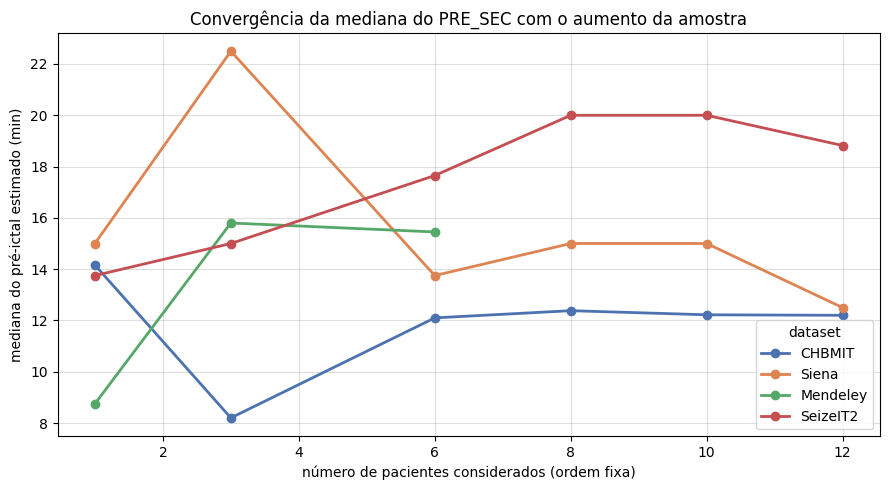

In [11]:
# Mediana cumulativa do pré-ictal estimado por dataset
INCREMENTOS = {
    'CHBMIT'  : [1, 3, 6, 8, 10, 12],
    'Siena'   : [1, 3, 6, 8, 10, 12],
    'SeizeIT2': [1, 3, 6, 8, 10, 12],
    'Mendeley': [1, 3, 6],
}

convergence = []
for ds in DATASETS:
    if ds not in df_calib['dataset'].values:
        continue
    pat_order = PATIENTS[ds]
    for k in INCREMENTOS[ds]:
        subset = pat_order[:k]
        ests = df_calib[(df_calib['dataset'] == ds) & (df_calib['patient'].isin(subset))]['preictal_est_min'].dropna()
        if len(ests) == 0:
            continue
        convergence.append(dict(dataset=ds, n_pacientes=k,
                                n_crises=len(ests),
                                mediana_min=round(float(ests.median()), 2)))
df_conv = pd.DataFrame(convergence)
if df_conv.empty:
    print('Sem dados de convergência (calibração não produziu estimativas).')
else:
    ipd.display(df_conv)

    fig, ax = plt.subplots(figsize=(9, 5))
    for ds in DATASETS:
        sub = df_conv[df_conv['dataset'] == ds]
        if sub.empty:
            continue
        ax.plot(sub['n_pacientes'], sub['mediana_min'], marker='o', linewidth=2,
                color=DS_COLORS[ds], label=ds)
    ax.set_xlabel('número de pacientes considerados (ordem fixa)')
    ax.set_ylabel('mediana do pré-ictal estimado (min)')
    ax.set_title('Convergência da mediana do PRE_SEC com o aumento da amostra')
    ax.legend(title='dataset')
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'convergencia_preictal.png'), dpi=140, bbox_inches='tight')
    plt.show()


## 4. Distribuição das estimativas

Estimativa de janela pré-ictal por dataset:


,count,median,mean,std
dataset,,,,
CHBMIT,55,12.2,14.4,9.6
Mendeley,26,15.4,17.1,10.3
SeizeIT2,36,18.8,20.1,10.9
Siena,25,12.5,16.2,10.9


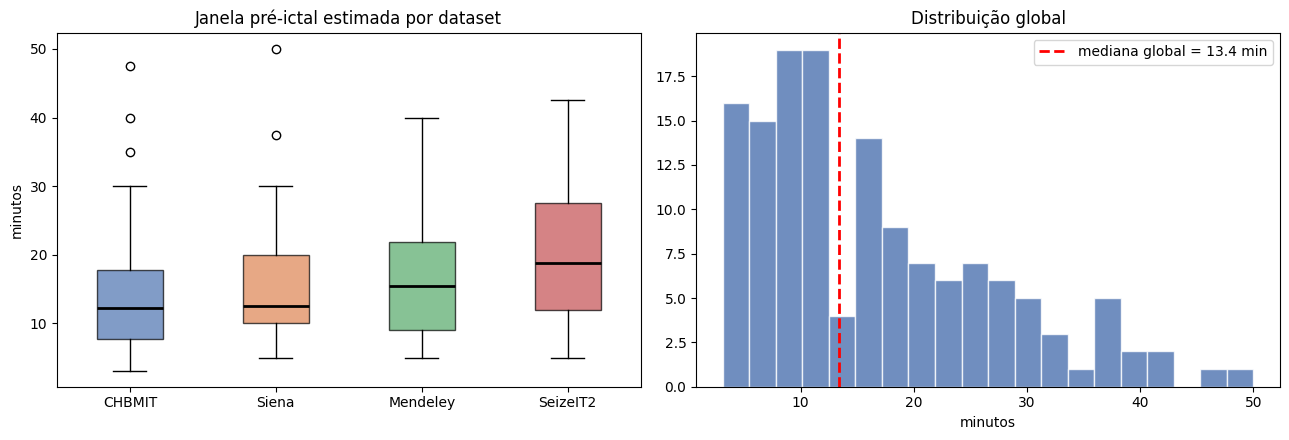

In [12]:
if not df_calib.empty:
    print('Estimativa de janela pré-ictal por dataset:')
    summ = df_calib.groupby('dataset')['preictal_est_min'].agg(['count', 'median', 'mean', 'std']).round(1)
    ipd.display(summ)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    data_box = [df_calib[df_calib['dataset'] == d]['preictal_est_min'].dropna().values
                for d in DATASETS if d in df_calib['dataset'].values]
    labels_box = [d for d in DATASETS if d in df_calib['dataset'].values]
    bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, d in zip(bp['boxes'], labels_box):
        patch.set_facecolor(DS_COLORS[d]); patch.set_alpha(0.7)
    axes[0].set_title('Janela pré-ictal estimada por dataset')
    axes[0].set_ylabel('minutos')
    axes[1].hist(df_calib['preictal_est_min'].dropna(), bins=20, color='#4C72B0', alpha=0.8, edgecolor='white')
    gmed = df_calib['preictal_est_min'].median()
    axes[1].axvline(gmed, color='red', linestyle='--', linewidth=2, label=f'mediana global = {gmed:.1f} min')
    axes[1].set_title('Distribuição global')
    axes[1].set_xlabel('minutos'); axes[1].legend()
    plt.tight_layout(); plt.savefig(os.path.join(VIZ_DIR, 'preictal_estimate.png'), dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('Nenhuma estimativa válida. Verifique os sinais do Notebook 1.')

## 5. Definição de `PRE_SEC`

Adota-se a mediana global das estimativas válidas, limitada ao intervalo [5, 30] min.


In [13]:
if not df_calib.empty:
    PRE_MIN_GLOBAL = float(df_calib['preictal_est_min'].median())
else:
    PRE_MIN_GLOBAL = 30.0
PRE_MIN_GLOBAL = float(np.clip(PRE_MIN_GLOBAL, 5, 30))
PRE_SEC = int(round(PRE_MIN_GLOBAL * 60))

estimate = dict(
    pre_sec=PRE_SEC, pre_min=round(PRE_MIN_GLOBAL, 2),
    n_estimates=int(len(df_calib)),
    n_reliable=int(df_calib['reliable'].sum()) if not df_calib.empty else 0,
    method='mediana global PELT', post_sec=POST_SEC, guard_sec=GUARD_SEC,
)
with open(OUT_JSON, 'w') as f:
    json.dump(estimate, f, indent=2)
print(f'PRE_SEC = {PRE_SEC} s ({PRE_MIN_GLOBAL:.1f} min)')
print(json.dumps(estimate, indent=2))

PRE_SEC = 806 s (13.4 min)
{
  "pre_sec": 806,
  "pre_min": 13.44,
  "n_estimates": 142,
  "n_reliable": 137,
  "method": "mediana global PELT",
  "post_sec": 1200,
  "guard_sec": 300
}


## 6. Funções de rotulagem

Três casos conforme a fonte de interictal:

**Gravação com crise (CHB-MIT, SeizeIT2).** Ictal entre início e fim; pré-ictal nos `PRE_SEC` anteriores (após a zona de transição do evento anterior); pós-ictal nos `POST_SEC` posteriores; interictal apenas a partir de `GAP_FREE_SEC` de distância de qualquer crise.

**Gravação sem crise (CHB-MIT, SeizeIT2).** Sinal inteiro rotulado como interictal.

**Intervalo intra-arquivo (Siena, Mendeley).** Mesma marcação de eventos; o interictal vem de regiões distantes (antes e depois), com a margem reduzida progressivamente caso necessário.


In [8]:
def label_seizure_file(n_samples, sfreq, intervals):
    '''Rotula uma gravação com crise. Retorna vetor int8 de tamanho n_samples.'''
    lab = np.full(n_samples, LBL['unknown'], dtype=np.int8)
    pre_n = int(PRE_SEC * sfreq); post_n = int(POST_SEC * sfreq)
    guard_n = int(GUARD_SEC * sfreq); free_n = int(GAP_FREE_SEC * sfreq)
    iv = sorted([(int(o * sfreq), int(e * sfreq)) for o, e in intervals])
    far = np.ones(n_samples, dtype=bool)
    for (o, e) in iv:
        far[max(0, o - free_n):min(n_samples, e + free_n)] = False
    lab[far] = LBL['interictal']
    for (o, e) in iv:
        lab[e:min(n_samples, e + post_n)] = LBL['postictal']
    for k, (o, e) in enumerate(iv):
        prev_e = iv[k - 1][1] if k > 0 else 0
        pre_start = max(prev_e + guard_n, o - pre_n)
        if o - pre_start >= int(MIN_PRE_SEC * sfreq):
            lab[pre_start:o] = LBL['preictal']
    for (o, e) in iv:
        lab[o:e] = LBL['ictal']
    return lab

def label_free_file(n_samples):
    '''Gravação sem crise: tudo interictal.'''
    return np.full(n_samples, LBL['interictal'], dtype=np.int8)

def label_gap_file(n_samples, sfreq, intervals, margins=GAP_FALLBACKS, post_margin=POST_MARGIN_SEC):
    '''Rotula eventos e marca interictal em regiões distantes (pré e pós-crise).
       Tenta margens decrescentes. Retorna (labels, margem_usada_s, n_amostras_interictal).'''
    pre_n = int(PRE_SEC * sfreq); post_n = int(POST_SEC * sfreq); guard_n = int(GUARD_SEC * sfreq)
    iv = sorted([(int(o * sfreq), int(e * sfreq)) for o, e in intervals])
    base = np.full(n_samples, LBL['unknown'], dtype=np.int8)
    for (o, e) in iv:
        base[e:min(n_samples, e + post_n)] = LBL['postictal']
    for k, (o, e) in enumerate(iv):
        prev_e = iv[k - 1][1] if k > 0 else 0
        pre_start = max(prev_e + guard_n, o - pre_n)
        if o - pre_start >= int(MIN_PRE_SEC * sfreq):
            base[pre_start:o] = LBL['preictal']
    for (o, e) in iv:
        base[o:e] = LBL['ictal']
    for margin in margins:
        lab = base.copy(); free_n = int(margin * sfreq); pm_n = int(post_margin * sfreq)
        far = np.ones(n_samples, dtype=bool)
        for (o, e) in iv:
            far[max(0, o - free_n):min(n_samples, e + max(free_n, pm_n))] = False
        mask = far & (lab == LBL['unknown'])
        lab[mask] = LBL['interictal']
        n_inter = int((lab == LBL['interictal']).sum())
        if n_inter > 0:
            return lab, margin, n_inter
    return base, margins[-1], 0

print('Funções de rotulagem definidas.')

Funções de rotulagem definidas.


## 7. Rotulagem e gravação

Cada sinal é rotulado conforme sua fonte de interictal e gravado em `_L1.npz`. Casos de intervalo intra-arquivo com margem reduzida ou sem interictal são registrados em log.


In [9]:
gap_log = []; summary = []

def patient_in_target(ds, pat):
    return ds in PATIENTS and pat in PATIENTS[ds]

signal_files = sorted(glob.glob(os.path.join(SIGNAL_DIR, '*_signal.npz')))
for npz_path in tqdm(signal_files, desc='Rotulagem'):
    base = os.path.basename(npz_path)
    m = re.match(r'(.+?)__(.+?)__(.+)_signal\.npz', base)
    if not m:
        continue
    ds, pat, fkey = m.group(1), m.group(2), m.group(3)
    if not patient_in_target(ds, pat):
        continue
    out = os.path.join(L1_DIR, f'{ds}__{pat}__{fkey}_L1.npz')
    if os.path.exists(out):
        continue
    try:
        # Carregar apenas metadados leves — NÃO carregar o array 'data'
        npz   = np.load(npz_path, allow_pickle=True)
        sfreq = float(npz['sfreq'])
        chs   = list(npz['ch_names'])
        seiz  = npz['seizure_intervals']
        n     = int(npz['data'].shape[1])     # shape não carrega o array completo no npz lazy
        iv    = [(float(s), float(e)) for s, e in seiz] if len(seiz) > 0 else []
        npz.close(); del npz; gc.collect()    # libera imediatamente — não precisamos do sinal
    except Exception as e:
        print(f'  {base}: {e}'); continue

    # Gerar vetor de rótulos (apenas int8 — mínimo de RAM)
    if not iv:
        labels = label_free_file(n)
    elif ds in GAP_DATASETS:
        labels, margin, _ = label_gap_file(n, sfreq, iv)
        gap_log.append(dict(dataset=ds, patient=pat, file=fkey,
                            margin_min=margin // 60,
                            interictal_min=round(int((labels == 0).sum()) / sfreq / 60, 1)))
    else:
        labels = label_seizure_file(n, sfreq, iv)

    # _L1.npz guarda apenas rótulos e metadados — NÃO o sinal.
    # O NB3 lê o sinal diretamente do _signal.npz original.
    np.savez_compressed(
        out,
        labels=labels,
        sfreq=np.float32(sfreq),
        ch_names=np.array(chs),
        dataset=np.str_(ds),
        n_samples=np.int64(n),
    )
    summary.append(dict(dataset=ds, patient=pat, file=fkey,
                        n_pre=int((labels == 1).sum()), n_ictal=int((labels == 2).sum()),
                        n_inter=int((labels == 0).sum()),
                        pre_min=round((labels == 1).sum() / sfreq / 60, 1),
                        inter_min=round((labels == 0).sum() / sfreq / 60, 1)))
    del labels; gc.collect()

print(f'Rotulagem concluída: {len(summary)} arquivos _L1.npz gerados.')

Rotulagem: 100%|██████████| 314/314 [05:15<00:00,  1.01s/it]

Rotulagem concluída: 314 arquivos _L1.npz gerados.


## 8. Resumo da rotulagem

In [10]:
df_sum = pd.DataFrame(summary)
if not df_sum.empty:
    print('Resumo por dataset (minutos por classe):')
    g = df_sum.groupby('dataset').agg(
        arquivos=('file', 'count'),
        preictal_min=('pre_min', 'sum'),
        interictal_min=('inter_min', 'sum'),
        amostras_pre=('n_pre', 'sum'),
        amostras_inter=('n_inter', 'sum')).round(1).reset_index()
    ipd.display(g)
    df_sum.to_csv(os.path.join(LOG_DIR, 'rotulagem_resumo.csv'), index=False)

if gap_log:
    df_gap = pd.DataFrame(gap_log)
    reduced = df_gap[df_gap['margin_min'] < 60]
    zero = df_gap[df_gap['interictal_min'] == 0]
    print(f'\nIntervalo intra-arquivo: {len(df_gap)} arquivos processados')
    print(f'  com margem reduzida (< 60 min): {len(reduced)}')
    print(f'  sem interictal próprio: {len(zero)}')
    if len(zero):
        print('  arquivos sem interictal próprio:')
        ipd.display(zero)
    df_gap.to_csv(os.path.join(LOG_DIR, 'gap_log.csv'), index=False)

print('\nRotulagem concluída. Próximo: Notebook 3.')

Resumo por dataset (minutos por classe):


,dataset,arquivos,preictal_min,interictal_min,amostras_pre,amostras_inter
0,CHBMIT,172,942.0,11789.0,14493440,181074944
1,Mendeley,20,443.2,669.7,6809088,10286848
2,SeizeIT2,88,515.4,48215.4,7922688,740590592
3,Siena,34,477.2,3912.4,7342592,60097280



Intervalo intra-arquivo: 52 arquivos processados
  com margem reduzida (< 60 min): 10
  sem interictal próprio: 5
  arquivos sem interictal próprio:


,dataset,patient,file,margin_min,interictal_min
4,Mendeley,p11,p11_Record3,30,0.0
8,Mendeley,p12,p12_Record3,30,0.0
12,Mendeley,p13,p13_Record4,30,0.0
14,Mendeley,p14,p14_Record2,30,0.0
41,Siena,PN12,PN12-3,30,0.0



Rotulagem concluída. Próximo: Notebook 3.
